In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [25]:
df = pd.read_csv('C:/Users/Admin/Downloads/csv_file_transformed.csv')
df.head(2)

,month,town,resale_price,storey_range,flat_type,flat_model,lease_commence_date,remaining_lease_years,remaining_lease_months,floor_area_sqm,...,y,latitude,longitude,closest_mrt_station,distance_to_mrt_meters,transport_type,line_color,distance_to_cbd,closest_pri_school,distance_to_pri_school_meters
0,2017-01-01,ANG MO KIO,232000.0,10 TO 12,2 ROOM,Improved,1979-05-01,61,4,44.0,...,38229.067463,1.362005,103.853880,Ang Mo Kio,999.941618,MRT,Red,8615.656983,TOWNSVILLE PRIMARY SCHOOL,218.125254
1,2017-01-01,ANG MO KIO,250000.0,01 TO 03,3 ROOM,New Generation,1978-08-01,60,7,67.0,...,39220.009892,1.370966,103.838202,Ang Mo Kio,1268.958246,MRT,Red,9715.131951,ANG MO KIO PRIMARY SCHOOL,241.572335


Text(0.5, 1.0, 'Histogram of Remaining_lease_years')

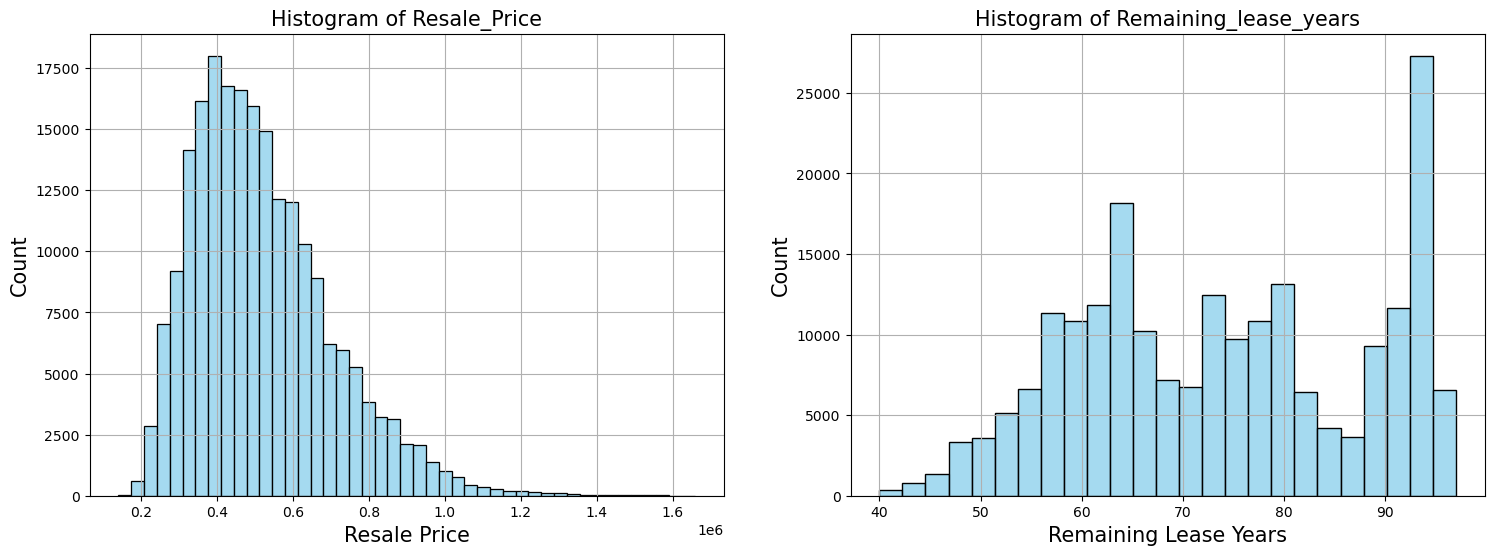

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(18, 6))
ax1 = sns.histplot(data=df, x='resale_price', bins=45, color='skyblue', ax=ax[0])
ax1.set_xlabel('Resale Price', fontsize=15)
ax1.set_ylabel('Count', fontsize=15)
ax1.grid(True)
ax1.set_title('Histogram of Resale_Price', fontsize=15)

ax2 = sns.histplot(data=df, x='remaining_lease_years', bins=25, color='skyblue', ax=ax[1])
ax2.set_xlabel('Remaining Lease Years', fontsize=15)
ax2.set_ylabel('Count', fontsize=15)
ax2.grid(True)
ax2.set_title('Histogram of Remaining_lease_years', fontsize=15)

```
Resale Price:

Most flats are in the 0.3–0.6 million SGD range, with fewer very expensive flats.

A small number of flats go above 1 million SGD → outliers.

The resale market is dominated by affordable to mid-range flats, with very few high-end properties.

...

Remaining Lease Years:

Uneven, multimodal distribution.

Range: Between 40 to 99 years.

Noticeable peaks around 60–70 years and 90–99 years.

Very few flats have leases below 50 years.

Many HDB flats still have long leases (especially close to 99 years), while another significant group is around 60–70 years, reflecting different development periods.

Note:  Tree-based models are usually better for features like remaining_lease_years with peaks or non-linear effects.

Text(0.5, 1.0, 'Histogram of Floor Area Sqft.')

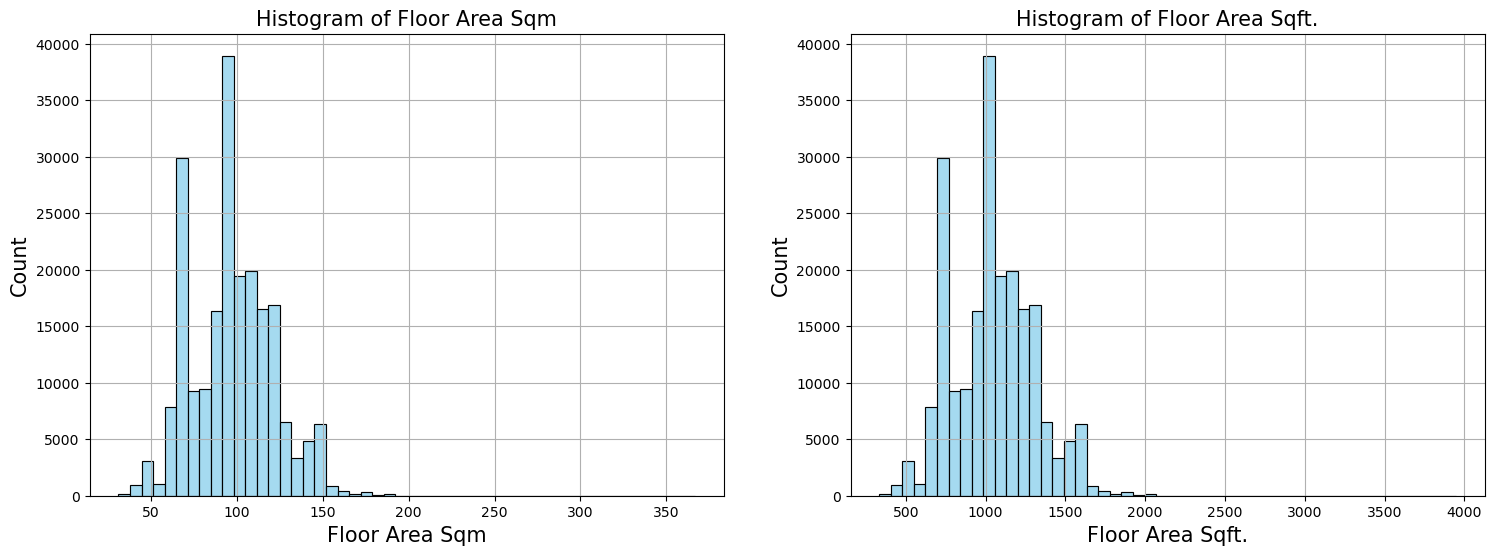

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(18, 6))
ax1 = sns.histplot(data=df, x='floor_area_sqm', bins=50, color='skyblue', ax=ax[0])
ax1.set_xlabel('Floor Area Sqm', fontsize=15)
ax1.set_ylabel('Count', fontsize=15)
ax1.grid(True)
ax1.set_title('Histogram of Floor Area Sqm', fontsize=15)

ax2 = sns.histplot(data=df, x='floor_area_sqft', bins=50, color='skyblue', ax=ax[1])
ax2.set_xlabel('Floor Area Sqft.', fontsize=15)
ax2.set_ylabel('Count', fontsize=15)
ax2.grid(True)
ax2.set_title('Histogram of Floor Area Sqft.', fontsize=15)

```
Histogram of Floor Area (Sqm):
Shape: Right-skewed, but not too extreme.

Range: Common sizes between 70–150 sqm, with a concentration around 100 sqm.

Observation:

Flats above 200 sqm are rare (outliers).

Interpretation: Most flats are medium-sized (standard 3–5 room flats), while very large flats (>200 sqm) are uncommon.

...

Histogram of Floor Area (Sqft):
Shape: Similar to sqm version, just scaled up (1 sqm ≈ 10.76 sqft).

Range: Most flats between 700–1500 sqft, peaking around 1000–1100 sqft.

Observation:

Very large flats (>2500 sqft) are rare.

Interpretation: Typical flat sizes are around 1000 sqft, with very few exceptionally large units.

Text(0.5, 1.0, 'Histogram of Distance_to_pri_school_meters')

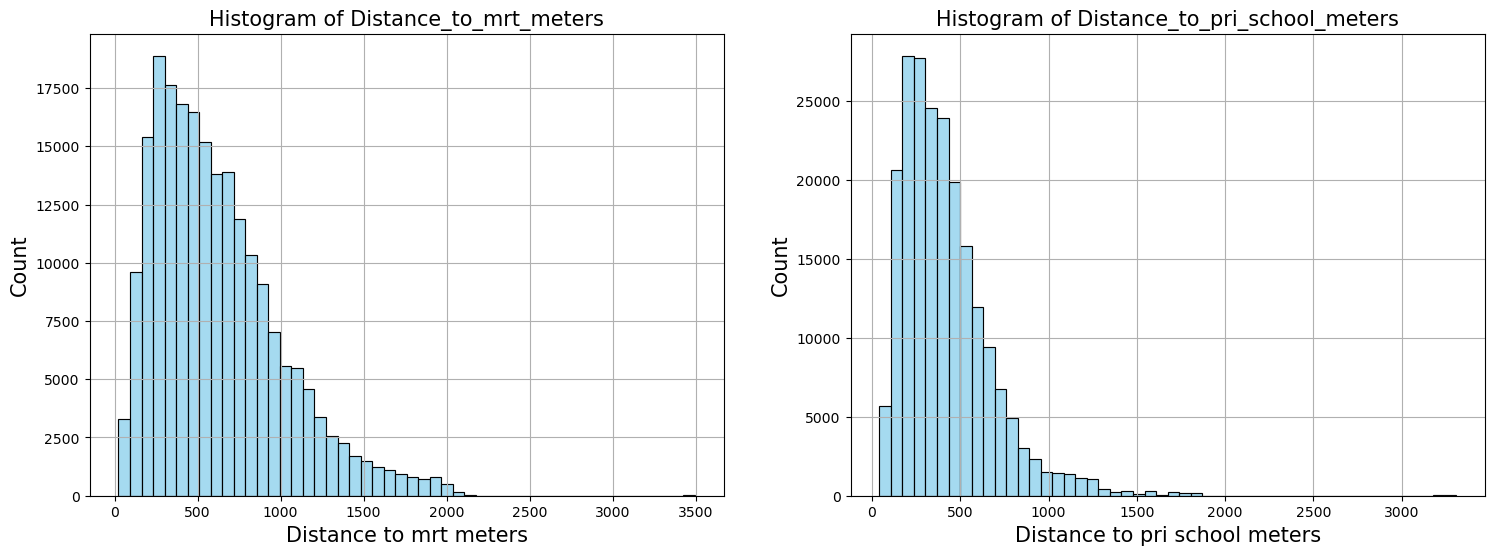

In [33]:
fig, ax = plt.subplots(1, 2, figsize=(18, 6))
ax1 = sns.histplot(data=df, x='distance_to_mrt_meters', bins=50, color='skyblue', ax=ax[0])
ax1.set_xlabel('Distance to mrt meters', fontsize=15)
ax1.set_ylabel('Count', fontsize=15)
ax1.grid(True)
ax1.set_title('Histogram of Distance_to_mrt_meters', fontsize=15)

ax2 = sns.histplot(data=df, x='distance_to_pri_school_meters', bins=50, color='skyblue', ax=ax[1])
ax2.set_xlabel('Distance to pri school meters', fontsize=15)
ax2.set_ylabel('Count', fontsize=15)
ax2.grid(True)
ax2.set_title('Histogram of Distance_to_pri_school_meters', fontsize=15)

```
Histogram of Distance to MRT (meters):
Shape: Right-skewed (positively skewed).

Peak: Most flats are clustered around 200–600 meters from an MRT station.

Spread: The frequency gradually declines as distance increases. Very few flats are beyond 2000 meters, with almost none past 3000 meters.

Interpretation: Most flats are located within walking distance (~500m) of MRT stations, which is typical for Singapore’s urban planning. Being close to MRT is a key housing feature, so the high concentration near MRT is expected. Flats very far from MRTs are rare.

Histogram of Distance to Primary School (meters):
Shape: Also right-skewed.

Peak: Highest concentration is between 100–400 meters from a school.

Spread: Most flats are within 1 km of a school. Very few exceed 2000 meters, with rare outliers up to ~3000m.

Interpretation: Most flats are very close to primary schools, reflecting the fact that Singapore has many schools distributed across neighborhoods. The government ensures accessibility to schools, so long distances are uncommon.

Overall Insights
Both MRT and school distances follow a right-skewed pattern: majority of flats are near, and only a small tail extends far.

Urban planning impact: Singapore’s policy of ensuring accessibility means:

Most households are within 500m–1km of both an MRT station and a primary school.

Flats that are farther away may be less desirable and could impact resale prices.

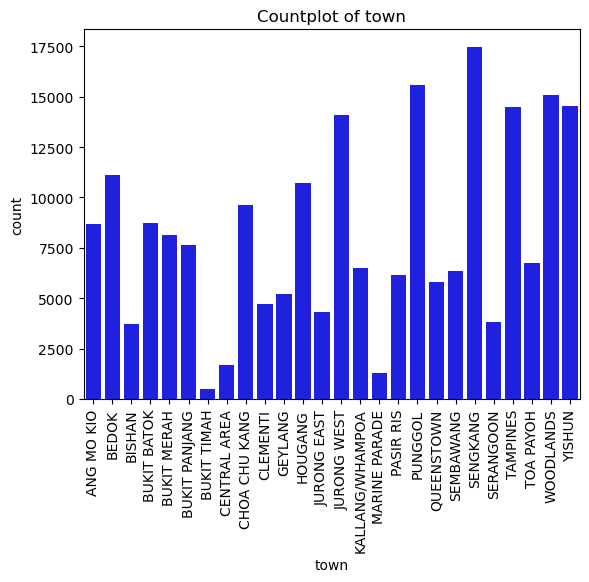

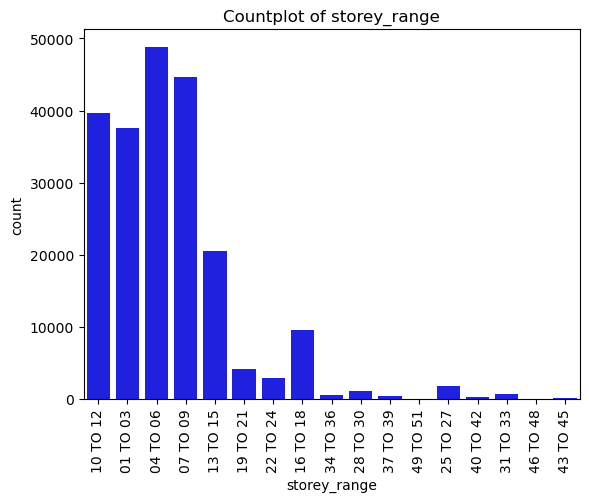

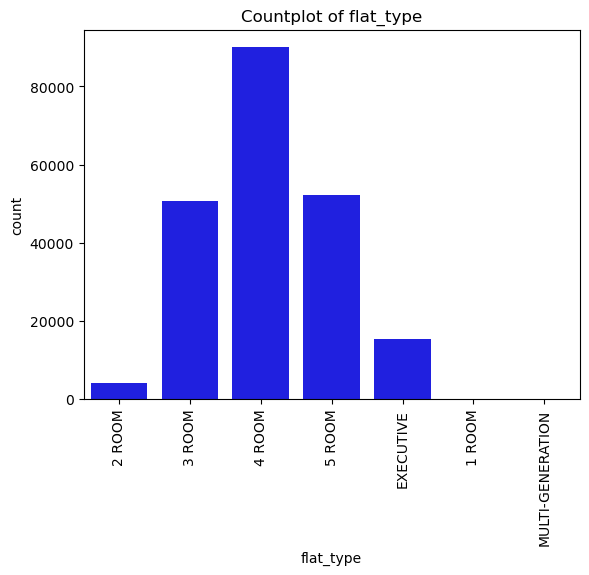

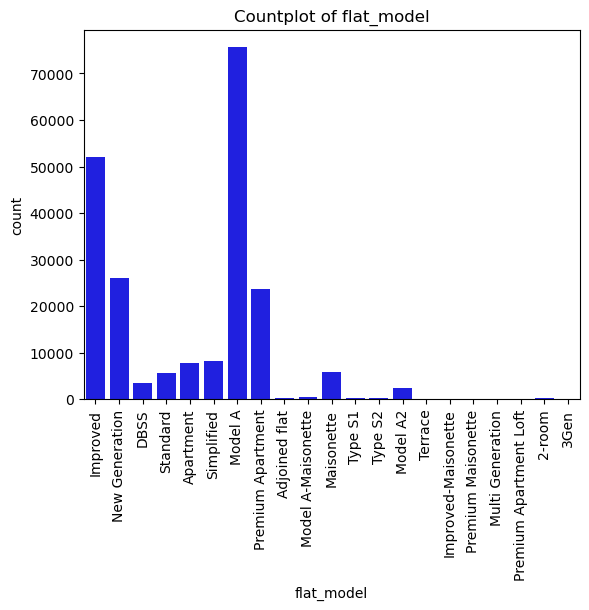

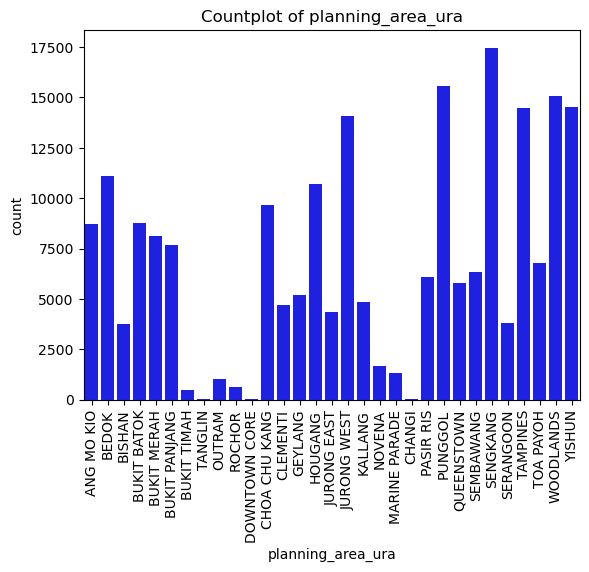

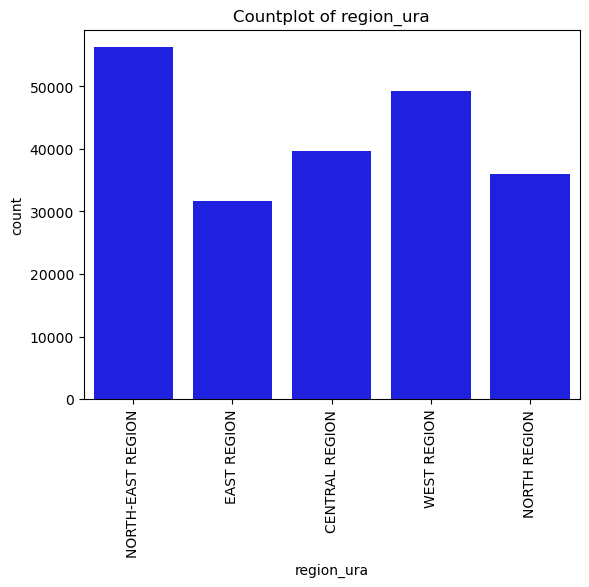

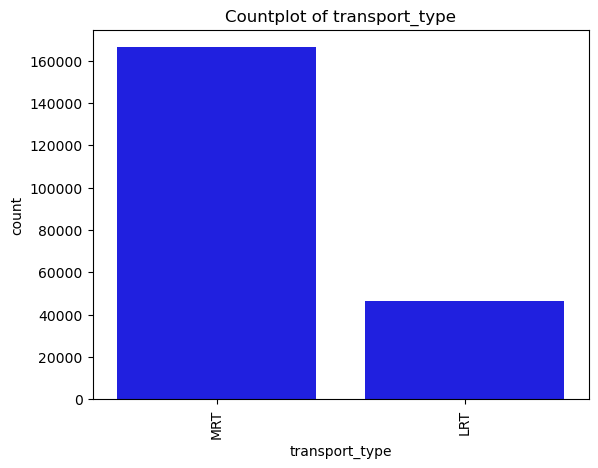

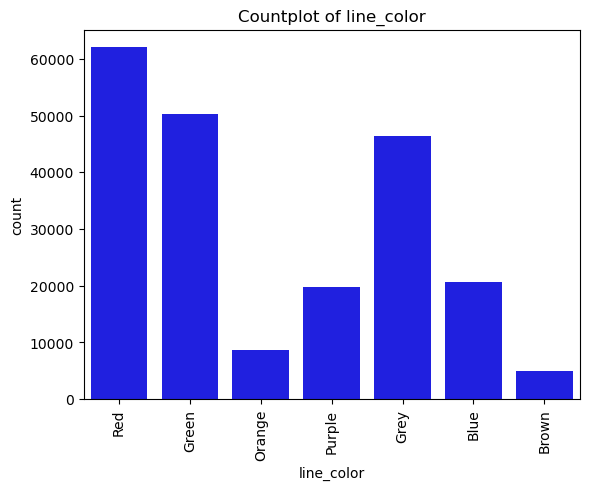

In [44]:
cat_cols = df.drop(labels=['month', 'lease_commence_date', 'closest_mrt_station', 'closest_pri_school'], axis=1).select_dtypes('object').columns.tolist()
for col in cat_cols:
    sns.countplot(data=df, x=col, color='blue')
    plt.xticks(rotation=90)
    print()
    plt.title(f'Countplot of {col}')
    plt.show()

```
Resale happened in some towns a lot.

7x-9x more resale happened in 10 to 50 storey range.

Most flat type was 3-5 rooms in reselling.

Model-A & Improved flat model sold a lot while New generation and Premium Apartment sold less than Model-A and Improved model. Others (i.e., Model-2, Model-A-Maisonette) sold much less.

Most resell happened in Nort-East Region.

People valuede MRT transport type more as we can see the count of MRT is much more than LRT.

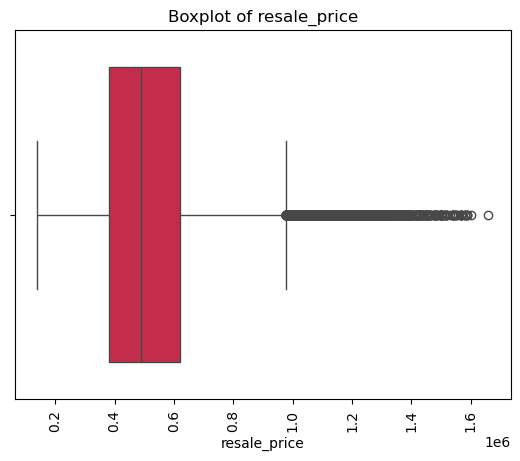

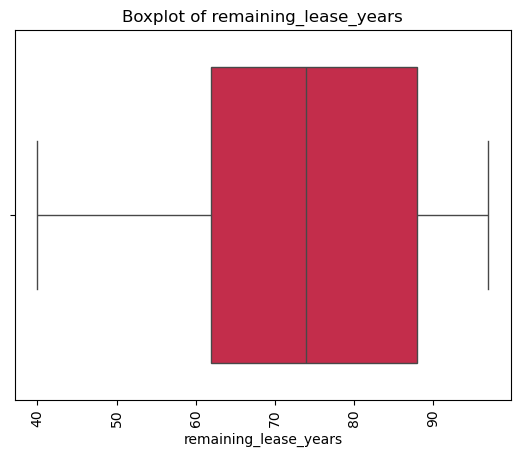

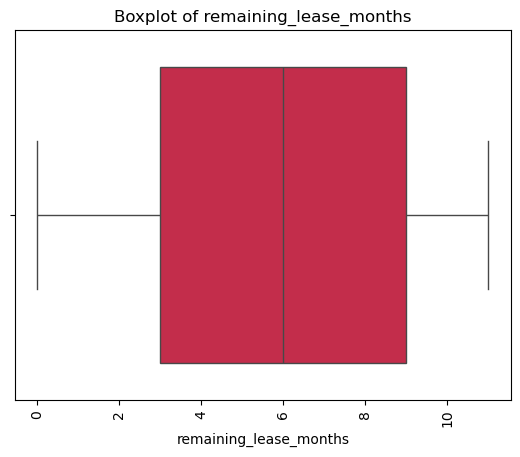

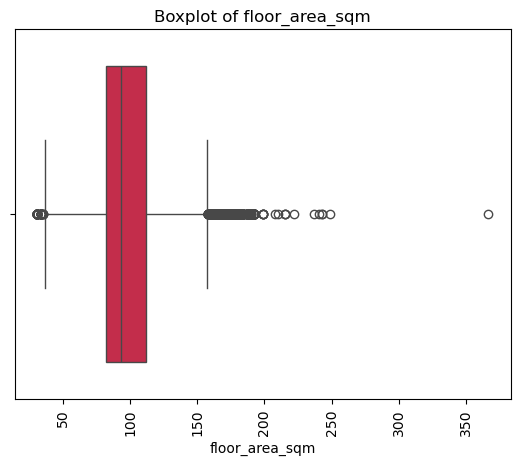

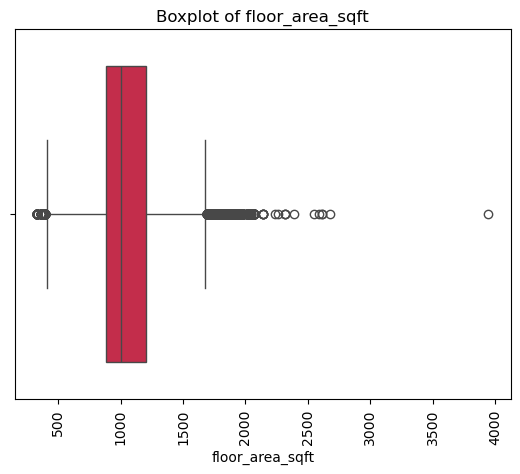

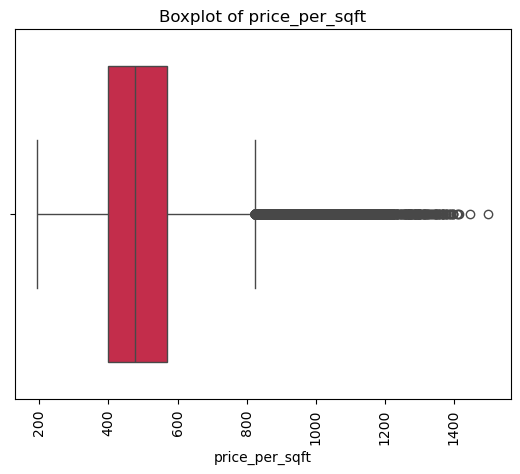

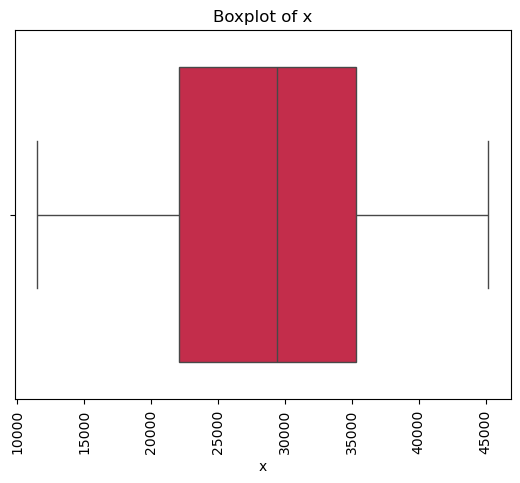

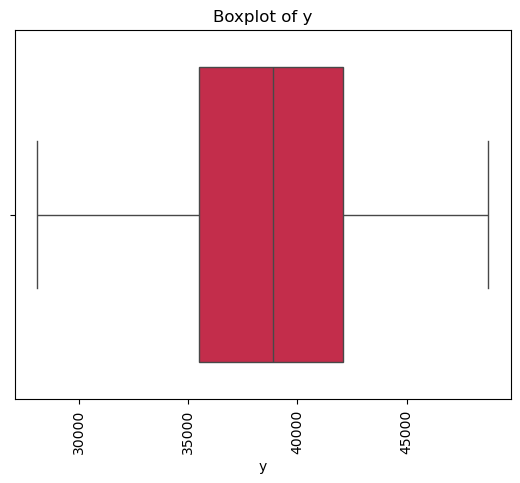

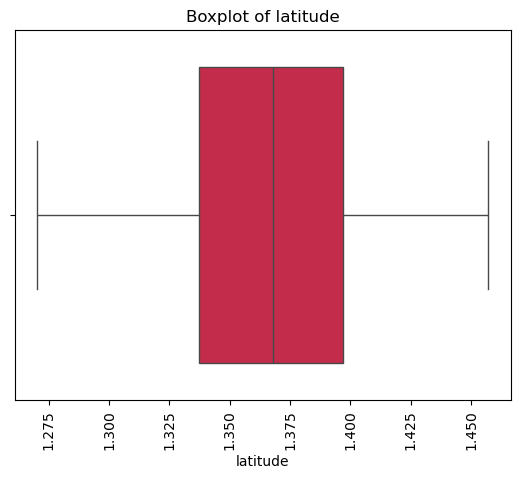

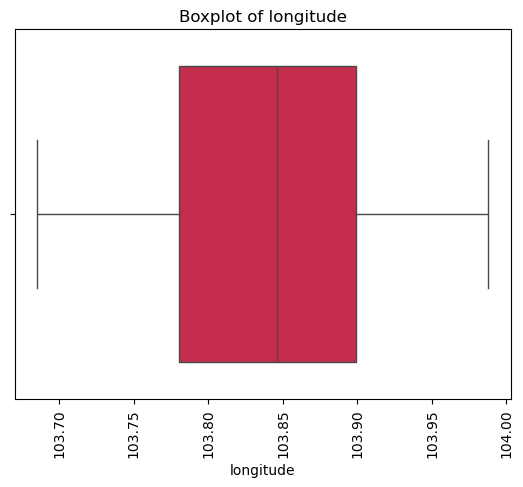

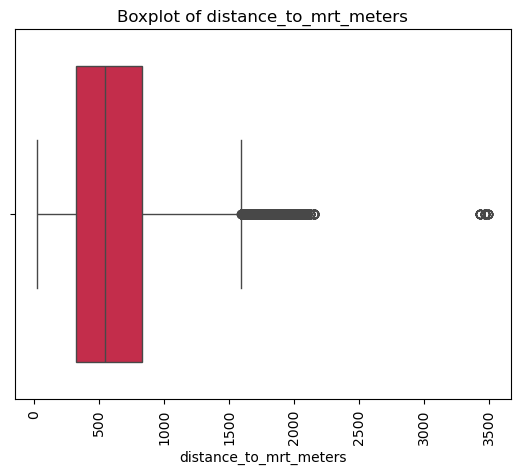

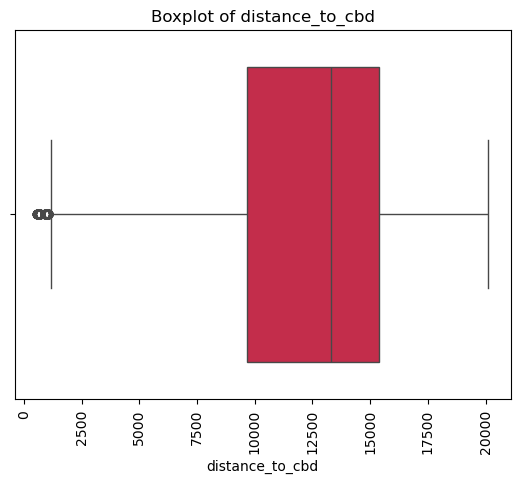

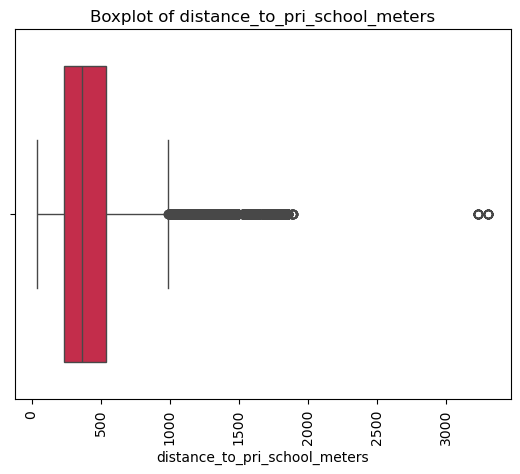

In [46]:
cat_cols = df.select_dtypes(['int64', 'float64']).columns.tolist()
for col in cat_cols:
    sns.boxplot(data=df, x=col, color='crimson')
    plt.xticks(rotation=90)
    print()
    plt.title(f'Boxplot of {col}')
    plt.show()

```
As we saw in historam, boxplot also indicates most outliers exit on Resale Price, Price Per Sqft etc.

While some features contains outliers also (i.e., distance_to_pre_school_meters, distance_to_mrt_meters) but not as much as the Resell Price and Price Per Sqft.